In [1]:
print("hello")

hello


In [3]:
from dotenv import load_dotenv
load_dotenv()
import os
os.environ['GROQ_API_KEY'] = os.getenv("GROQ_API_KEY")

In [4]:
model="deepseek-r1-distill-llama-70b"

### load the model

In [5]:
from langchain_groq import ChatGroq
llm = ChatGroq(model=model)
llm.invoke("HI")

AIMessage(content='<think>\n\n</think>\n\nHello! How can I assist you today? 😊', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 16, 'prompt_tokens': 4, 'total_tokens': 20, 'completion_time': 0.081409403, 'prompt_time': 6.6789e-05, 'queue_time': 0.20989432, 'total_time': 0.081476192}, 'model_name': 'deepseek-r1-distill-llama-70b', 'system_fingerprint': 'fp_1bbe7845ec', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id='run--61de7dba-f6d9-44b6-b992-67fbd3d8a337-0', usage_metadata={'input_tokens': 4, 'output_tokens': 16, 'total_tokens': 20})

In [7]:
print(llm.invoke("HI").content)

<think>

</think>

Hello! How can I assist you today? 😊


In [8]:
# import operator
# from typing import List
# from langgraph.graph.message import add_messages
# from pydantic import BaseModel , Field
# from typing import TypedDict, Annotated, Sequence
# from langchain_core.messages import BaseMessage
# from langchain_core.output_parsers import StrOutputParser
# from langchain_core.prompts import ChatPromptTemplate, PromptTemplate

from langchain_core.tools import tool
from langchain_core.messages import HumanMessage, AIMessage
from langgraph.graph import StateGraph,MessagesState,START,END
from langgraph.prebuilt import ToolNode

In [9]:
def call_model(state:MessagesState):
    message = state['messages']
    response = llm.invoke(message)
    return {"messages":[response]}

this code is only for testing

In [10]:
state={"messages":["hi hello how are you?"]}
call_model(state)

{'messages': [AIMessage(content="<think>\n\n</think>\n\nHello! I'm just a virtual assistant, so I don't have feelings, but I'm here and ready to help you with whatever you need. How are *you* doing? 😊", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 44, 'prompt_tokens': 9, 'total_tokens': 53, 'completion_time': 0.185080444, 'prompt_time': 0.000219056, 'queue_time': 0.204498192, 'total_time': 0.1852995}, 'model_name': 'deepseek-r1-distill-llama-70b', 'system_fingerprint': 'fp_1bbe7845ec', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id='run--c22ff722-a97a-475c-b9d1-aae000a3011b-0', usage_metadata={'input_tokens': 9, 'output_tokens': 44, 'total_tokens': 53})]}

### Design a simple workflow without tool calling/

In [11]:
workflow = StateGraph(MessagesState)

In [12]:
workflow.add_node("mybot",call_model)

In [13]:
workflow.add_edge(START,"mybot")

In [14]:
workflow.add_edge("mybot",END)

In [15]:
app = workflow.compile()

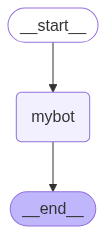

In [16]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [18]:
input ={"messages":["Hi helloe how are you"]}

In [19]:
app.invoke(input)

{'messages': [HumanMessage(content='Hi helloe how are you', additional_kwargs={}, response_metadata={}, id='dabb3863-1fa3-4929-be48-3a2d8314c3df'),
  AIMessage(content="<think>\n\n</think>\n\nHello! I'm just a virtual assistant, so I don't have feelings, but I'm here and ready to help you! How are you doing? 😊", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 38, 'prompt_tokens': 9, 'total_tokens': 47, 'completion_time': 0.163572503, 'prompt_time': 0.000506812, 'queue_time': 0.20462671000000002, 'total_time': 0.164079315}, 'model_name': 'deepseek-r1-distill-llama-70b', 'system_fingerprint': 'fp_1bbe7845ec', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id='run--0c0b982c-4f7c-447d-bbea-7fcee0c34aaa-0', usage_metadata={'input_tokens': 9, 'output_tokens': 38, 'total_tokens': 47})]}

In [20]:
for output in app.stream(input):
    for key,value in output.items():
        print(f"Output from {key} Node")
        print("_______")
        print(value)
        print("\n")

Output from mybot Node
_______
{'messages': [AIMessage(content="<think>\n\n</think>\n\nHello! I'm just a virtual assistant, so I don't have feelings, but I'm here and ready to help you. How are *you* doing? 😊", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 40, 'prompt_tokens': 9, 'total_tokens': 49, 'completion_time': 0.167730625, 'prompt_time': 0.000224686, 'queue_time': 0.20507192999999999, 'total_time': 0.167955311}, 'model_name': 'deepseek-r1-distill-llama-70b', 'system_fingerprint': 'fp_1bbe7845ec', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id='run--86db4fa9-f694-4f80-a893-3622ba66f747-0', usage_metadata={'input_tokens': 9, 'output_tokens': 40, 'total_tokens': 49})]}




### this is a workflow with tool calling

In [21]:
@tool
def search(query:str):
    """ This is my custom tool for searching weather"""
    if "delhi" in query.lower():
        return " the temp is 45 degree and sunny"
    return " the temp is 25 degree and cloudy"

#### testing the tool

In [22]:
search.invoke("what is weather in delhi")

' the temp is 45 degree and sunny'

In [23]:
search.invoke("what is weather in melbourne")

' the temp is 25 degree and cloudy'

In [24]:
search


StructuredTool(name='search', description='This is my custom tool for searching weather', args_schema=<class 'langchain_core.utils.pydantic.search'>, func=<function search at 0x11016cc20>)

In [25]:
llm.invoke("what is weather in delhi")

AIMessage(content="<think>\n\n</think>\n\nI don't have real-time weather data. To find the current weather in Delhi, you can check a reliable weather service like [AccuWeather](https://www.accuweather.com), [Weather.com](https://www.weather.com), or your local weather app. Let me know if you'd like help with anything else!", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 71, 'prompt_tokens': 9, 'total_tokens': 80, 'completion_time': 0.286331765, 'prompt_time': 0.000210489, 'queue_time': 0.20619016199999998, 'total_time': 0.286542254}, 'model_name': 'deepseek-r1-distill-llama-70b', 'system_fingerprint': 'fp_1bbe7845ec', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id='run--42b2a68d-1999-4b25-b204-1c0e8f2528a3-0', usage_metadata={'input_tokens': 9, 'output_tokens': 71, 'total_tokens': 80})

### Binding a tool to the LLM
Special Note: use some good for agentic workflow since opensource model might not give you the correct output

In [26]:
tools = [search]

In [27]:
llm_with_tool = llm.bind_tools(tools)

### testig my llm_with_tool

In [28]:
response = llm_with_tool.invoke("what is  weather in delhi")

In [29]:
response


AIMessage(content='', additional_kwargs={'reasoning_content': 'Okay, the user is asking about the weather in Delhi. I need to use the provided tool to find the information. The tool is called "search" and it requires a query parameter. I should structure the query as "weather in Delhi" to get accurate results. Let me format the tool call correctly with the function name and the query argument.\n', 'tool_calls': [{'id': 'rvfr4tp6n', 'function': {'arguments': '{"query":"weather in Delhi"}', 'name': 'search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 95, 'prompt_tokens': 131, 'total_tokens': 226, 'completion_time': 0.410970274, 'prompt_time': 0.008493386, 'queue_time': 0.205466273, 'total_time': 0.41946366}, 'model_name': 'deepseek-r1-distill-llama-70b', 'system_fingerprint': 'fp_1bbe7845ec', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--885869ed-9e83-40ea-9012-a596ff91c445-0', tool_calls=[{'name': 'search', '

In [30]:
response.content

''

In [31]:
response.tool_calls

[{'name': 'search',
  'args': {'query': 'weather in Delhi'},
  'id': 'rvfr4tp6n',
  'type': 'tool_call'}]

In [32]:
def call_model(state=MessagesState):
    question = state["messages"]
    response = llm_with_tool.invoke(question)
    return {"messages": [response]}

### testing code

In [33]:
input={"messages":["what is a weather in delhi?"]}

In [34]:
response = call_model(input)

In [37]:
response["messages"][-1].content

''

In [38]:

response["messages"][-1].tool_calls

[{'name': 'search',
  'args': {'query': 'Delhi weather'},
  'id': '4qcnwstwf',
  'type': 'tool_call'}]

### here my router function
now whatever will come from call_model router funtion will redirect this to the appropriate tool

In [39]:
def router_function(state:MessagesState):
    message = state['messages']
    last_message = message[-1]
    if last_message.tool_calls:
        return "tools"
    return END

In [40]:
tools

[StructuredTool(name='search', description='This is my custom tool for searching weather', args_schema=<class 'langchain_core.utils.pydantic.search'>, func=<function search at 0x11016cc20>)]

In [41]:
tool_node = ToolNode(tools)

In [42]:
tool_node

tools(tags=None, recurse=True, explode_args=False, func_accepts_config=True, func_accepts={'store': ('__pregel_store', None)}, tools_by_name={'search': StructuredTool(name='search', description='This is my custom tool for searching weather', args_schema=<class 'langchain_core.utils.pydantic.search'>, func=<function search at 0x11016cc20>)}, tool_to_state_args={'search': {}}, tool_to_store_arg={'search': None}, handle_tool_errors=True, messages_key='messages')

In [43]:
workflow2 = StateGraph(MessagesState)

In [44]:
workflow2.add_node("llmwithtool", call_model)

workflow2.add_node("mytools",tool_node)

workflow2.add_edge(START, "llmwithtool")

workflow2.add_conditional_edges( "llmwithtool",router_function,
                                {"tools":"mytools",
                                 END :END})

In [45]:
app2 = workflow2.compile()

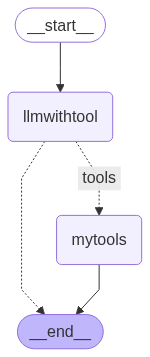

In [46]:
from IPython.display import Image, display
display(Image(app2.get_graph().draw_mermaid_png()))

In [47]:
response= app2.invoke({"messages":["what is a weather in syndey"]})

In [49]:
response["messages"][-1].content

' the temp is 25 degree and cloudy'

In [50]:
app2.invoke({"messages":["what is a weather in delhi?"]})

{'messages': [HumanMessage(content='what is a weather in delhi?', additional_kwargs={}, response_metadata={}, id='0c469998-45c8-4987-aff6-22587b75e738'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'Alright, the user is asking about the weather in Delhi. They used the phrase "what is a weather in delhi?" which seems like a typo. I think they meant "what is the weather in Delhi?" or "what\'s the weather like in Delhi?"\n\nI should correct that typo in my response to make it clear. Since I have a tool called "search" that\'s designed for weather searches, I should use that. The tool requires a query parameter, so I\'ll structure the arguments to pass "weather in Delhi" as the query.\n\nI need to make sure the JSON syntax is correct within the tool_call XML tags. I\'ll double-check that the function name is "search" and the arguments are properly formatted as a JSON object with the query string.\n', 'tool_calls': [{'id': 'y0m1hzrqg', 'function': {'arguments': '{"query"

### use good resoning based model

In [51]:
app2.invoke({"messages":["hi how are you?"]})

{'messages': [HumanMessage(content='hi how are you?', additional_kwargs={}, response_metadata={}, id='259b710f-395c-4b16-a36e-d3e023f5337d'),
  AIMessage(content="Hello! I'm here to help. How can I assist you today?", additional_kwargs={'reasoning_content': 'Okay, the user greeted me with "hi how are you?" which is a friendly opening. Since I\'m an AI, I don\'t have feelings, but I should respond politely. I\'ll say I\'m here to help and ask how I can assist them today. That should keep the conversation going smoothly.\n'}, response_metadata={'token_usage': {'completion_tokens': 82, 'prompt_tokens': 129, 'total_tokens': 211, 'completion_time': 0.367201888, 'prompt_time': 0.008364976, 'queue_time': 0.204023442, 'total_time': 0.375566864}, 'model_name': 'deepseek-r1-distill-llama-70b', 'system_fingerprint': 'fp_1bbe7845ec', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id='run--c73f2cf7-0b52-459d-b6e6-2ac08d940738-0', usage_metadata={'input_tokens': 129, 'outpu

In [52]:
workflow2.add_edge("mytools", "llmwithtool")

Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.


In [53]:
app3 = workflow2.compile()

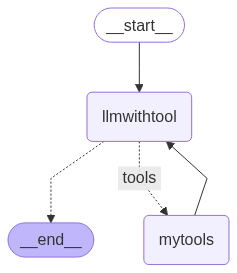

In [54]:
from IPython.display import Image, display
display(Image(app3.get_graph().draw_mermaid_png()))

In [55]:
for output in app3.stream({"messages":["what is the weather in melbourne"]}):
    for key, value in output.items():
        print(f"here is the output from {key}")
        print("_____")
        print(value)
        print("\n")

here is the output from llmwithtool
_____
{'messages': [AIMessage(content='', additional_kwargs={'reasoning_content': 'Okay, the user is asking about the weather in Melbourne. I need to figure out how to help them using the tools I have. I remember there\'s a function called "search" that\'s used for weather queries. \n\nFirst, I should check the function\'s requirements. It needs a "query" parameter which is a string. So, I\'ll structure the arguments with the query set to "weather in Melbourne". \n\nI need to make sure the JSON is correctly formatted. The function name is "search" and the arguments should be an object with "query" as the key. \n\nI\'ll put it all together within the <tool_call> tags as specified. That should trigger the search and provide the user with the current weather information they\'re looking for.\n', 'tool_calls': [{'id': 'dcsj9w6kj', 'function': {'arguments': '{"query":"weather in Melbourne"}', 'name': 'search'}, 'type': 'function'}]}, response_metadata={'t

In [ ]:
"what is a weather in delhi can you tell me some good hotel for staying in north delhi"

In [57]:
from langgraph.checkpoint.memory import MemorySaver

In [58]:
memory = MemorySaver()

In [59]:
workflow3=StateGraph(MessagesState)

workflow3.add_node("llmwithtool",call_model)

workflow3.add_node("mytools",tool_node)

workflow3.add_edge(START,"llmwithtool")

workflow3.add_conditional_edges("llmwithtool",
                                router_function,
                                {"tools":"mytools",
                                 END:END})

workflow3.add_edge("mytools","llmwithtool")

In [60]:
app4 = workflow3.compile(checkpointer=memory)

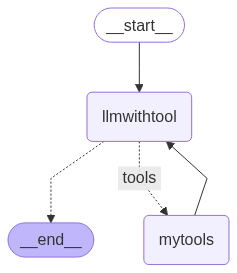

In [61]:

from IPython.display import Image, display
display(Image(app4.get_graph().draw_mermaid_png()))

In [62]:
config = {'configurable':{"thread_id":"1"}}

In [63]:
events = app4.stream({"messages":["what is the weather in new delhi?"]}, config=config, stream_mode="values")

In [64]:
for event in events :
    event["messages"][-1].pretty_print()

================================ Human Message =================================

what is the weather in new delhi?
================================== Ai Message ==================================
Tool Calls:
  search (c14b6tvj0)
 Call ID: c14b6tvj0
  Args:
    query: weather in New Delhi
================================= Tool Message =================================
Name: search

 the temp is 45 degree and sunny
================================== Ai Message ==================================

Got it! Let me know if you need more details about New Delhi or anything else.


In [65]:
events=app4.stream(
    {"messages":["what is a weather in indore?"]},config=config,stream_mode="values"
    )


In [66]:
for event in events:
    event["messages"][-1].pretty_print()

================================ Human Message =================================

what is a weather in indore?
================================== Ai Message ==================================
Tool Calls:
  search (140n2qdkr)
 Call ID: 140n2qdkr
  Args:
    query: weather in Indore
================================= Tool Message =================================
Name: search

 the temp is 25 degree and cloudy
================================== Ai Message ==================================

Sure! The temperature in Indore is 25 degrees and it's cloudy. Let me know if you need more details or assistance!


In [67]:
config

{'configurable': {'thread_id': '1'}}

In [68]:
memory.get(config)

{'v': 4,
 'ts': '2025-07-27T13:53:03.943306+00:00',
 'id': '1f06af10-43fb-6a54-8008-cc3cf4dc6f36',
 'channel_versions': {'__start__': '00000000000000000000000000000007.0.09724401728056431',
  'messages': '00000000000000000000000000000010.0.3293095152424721',
  'branch:to:llmwithtool': '00000000000000000000000000000010.0.3293095152424721',
  'branch:to:mytools': '00000000000000000000000000000009.0.9221154755032711'},
 'versions_seen': {'__input__': {},
  '__start__': {'__start__': '00000000000000000000000000000006.0.8921480746482531'},
  'llmwithtool': {'branch:to:llmwithtool': '00000000000000000000000000000009.0.9221154755032711'},
  'mytools': {'branch:to:mytools': '00000000000000000000000000000008.0.2203083655244873'}},
 'channel_values': {'messages': [HumanMessage(content='what is the weather in new delhi?', additional_kwargs={}, response_metadata={}, id='aa4c5559-ef1c-41de-ac72-3302d3d2f5f1'),
   AIMessage(content='', additional_kwargs={'reasoning_content': 'Alright, the user is as